<a href="https://colab.research.google.com/github/angiecombs11-ops/PurdueHW/blob/main/8_03_working_with_image_data4_5_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import matplotlib.pyplot as plt
%matplotlib inline

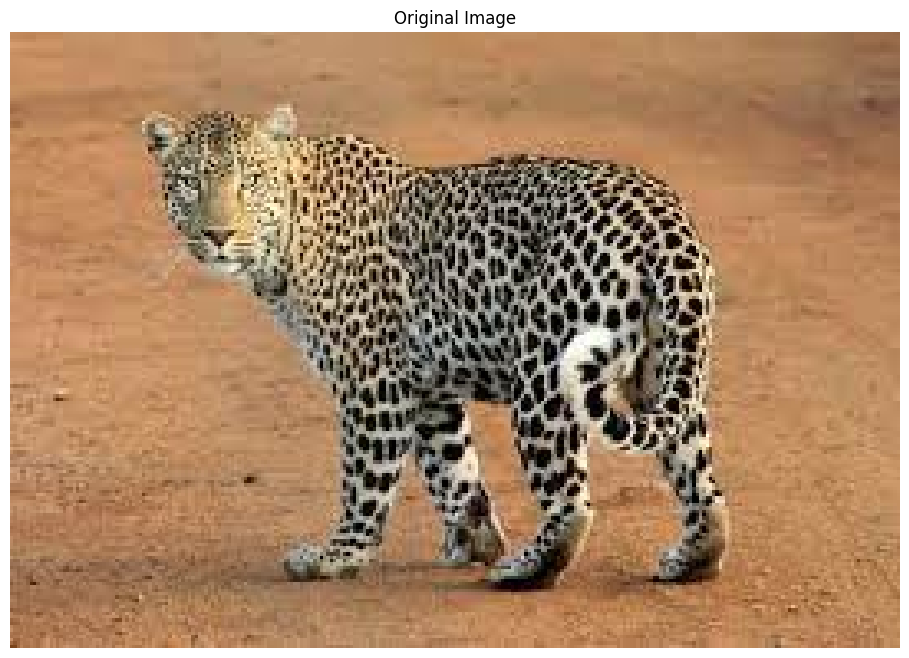

In [6]:
image = io.imread('leopard.jpg')
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.title("Original Image")
plt.show()

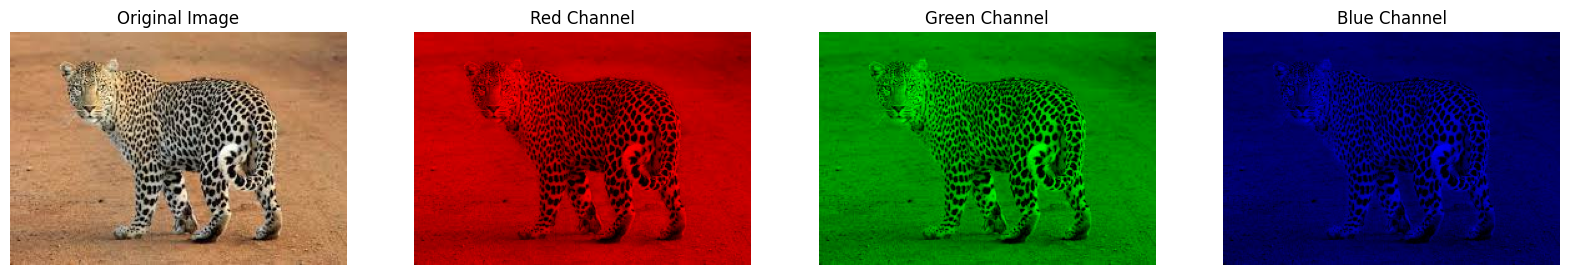

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Original Image', 'Red Channel', 'Green Channel', 'Blue Channel']

# Display the original image
axes[0].imshow(image)
axes[0].set_title(titles[0])
axes[0].axis('off')

# Function to isolate color channels
def isolate_channel(image, color_idx):
    # Create a zero matrix of the same shape as the image
    channel_image = np.zeros_like(image)
    # Copy the appropriate color channel's values into the matrix
    channel_image[:,:,color_idx] = image[:,:,color_idx]
    return channel_image

# Display Red Channel
red_image = isolate_channel(image, 0)  # Red channel is index 0
axes[1].imshow(red_image)
axes[1].set_title(titles[1])
axes[1].axis('off')

# Display Green Channel
green_image = isolate_channel(image, 1)  # Green channel is index 1
axes[2].imshow(green_image)
axes[2].set_title(titles[2])
axes[2].axis('off')

# Display Blue Channel
blue_image = isolate_channel(image, 2)  # Blue channel is index 2
axes[3].imshow(blue_image)
axes[3].set_title(titles[3])
axes[3].axis('off')

plt.show()


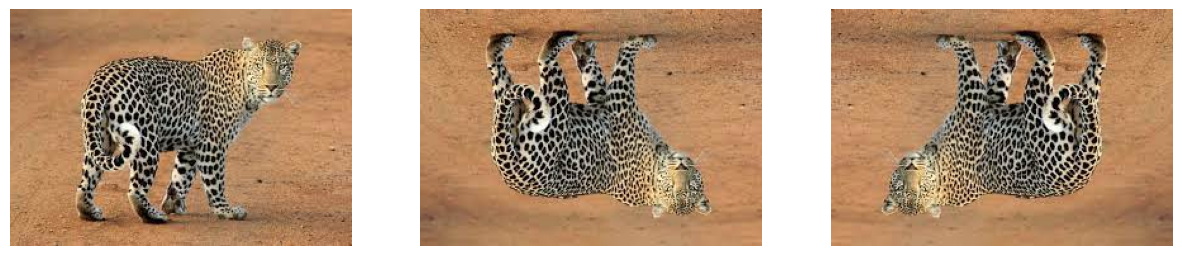

In [8]:
def display_augmented_images(datagen, image):
    samples = tf.expand_dims(image, 0)  # Expand image dimensions
    it = datagen.flow(samples, batch_size=1)
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        batch = next(it)
        img = batch[0].astype('uint8')
        plt.imshow(img)
        plt.axis('off')
    plt.show()

# Apply flip augmentation
flip_datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)
display_augmented_images(flip_datagen, image)

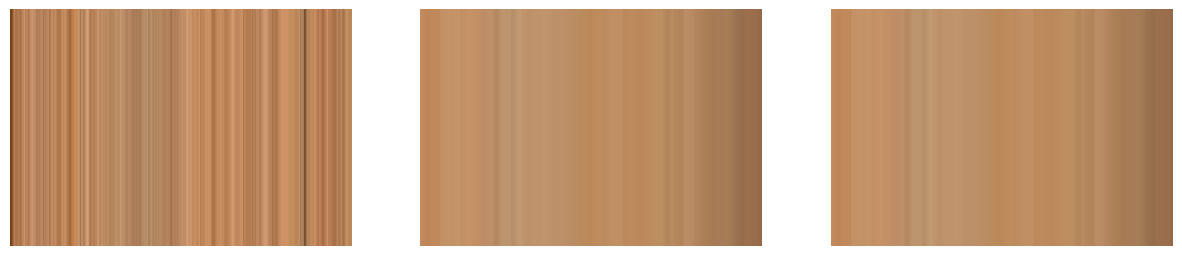

In [9]:
# Perform width shifting augmentation
width_shift_datagen = ImageDataGenerator(width_shift_range=[-200, 200])
display_augmented_images(width_shift_datagen, image)

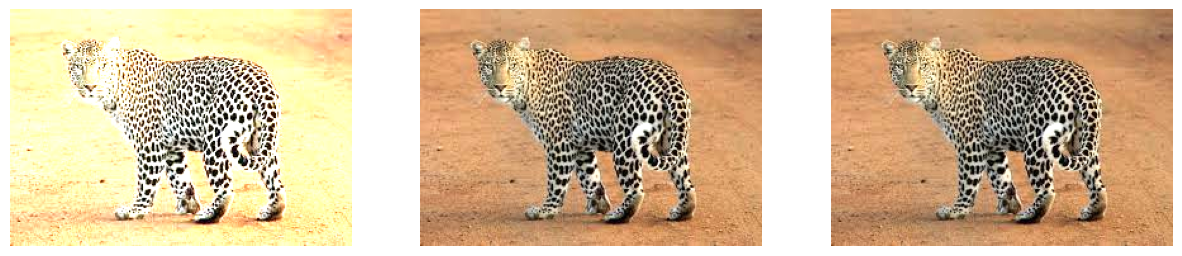

In [10]:
# Change brightness augmentation
brightness_datagen = ImageDataGenerator(brightness_range=[0.5, 2.0])
display_augmented_images(brightness_datagen, image)